# Ecommerce Analytics — Data Exploration

This notebook explores the raw (bronze) data generated by `hakio_data_project.py` and documents the data quality issues that informed the transform and validation rules in the SQL pipeline.

**Pipeline overview:** `bronze → transform (validate) → data_quality → silver → gold`

## 1. Import Required Libraries

In [28]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

con = duckdb.connect("data/analytics.duckdb", read_only=True)
print("Connected to analytics.duckdb")

Connected to analytics.duckdb


## 2. Load the Dataset

List all schemas and tables in the database, then load each bronze table into a DataFrame.

In [4]:
# Show all schemas and tables
con.sql("""
    SELECT table_schema, table_name, table_type
    FROM information_schema.tables
    ORDER BY table_schema, table_name
""").show()

┌──────────────┬───────────────────────┬────────────┐
│ table_schema │      table_name       │ table_type │
│   varchar    │        varchar        │  varchar   │
├──────────────┼───────────────────────┼────────────┤
│ bronze       │ order_lines           │ BASE TABLE │
│ bronze       │ orders                │ BASE TABLE │
│ bronze       │ products              │ BASE TABLE │
│ bronze       │ refunds               │ BASE TABLE │
│ data_quality │ order_lines           │ BASE TABLE │
│ data_quality │ orders                │ BASE TABLE │
│ data_quality │ products              │ BASE TABLE │
│ data_quality │ refunds               │ BASE TABLE │
│ gold         │ DimOrder              │ VIEW       │
│ gold         │ DimProduct            │ VIEW       │
│ gold         │ DimRefund             │ VIEW       │
│ gold         │ FactRefund            │ VIEW       │
│ silver       │ order_lines           │ BASE TABLE │
│ silver       │ orders                │ BASE TABLE │
│ silver       │ products   

In [5]:
# Load bronze tables into DataFrames
df_products = con.sql("SELECT * FROM bronze.products").df()
df_orders = con.sql("SELECT * FROM bronze.orders").df()
df_order_lines = con.sql("SELECT * FROM bronze.order_lines").df()
df_refunds = con.sql("SELECT * FROM bronze.refunds").df()

print(f"bronze.products:    {len(df_products):,} rows, {len(df_products.columns)} columns")
print(f"bronze.orders:      {len(df_orders):,} rows, {len(df_orders.columns)} columns")
print(f"bronze.order_lines: {len(df_order_lines):,} rows, {len(df_order_lines.columns)} columns")
print(f"bronze.refunds:     {len(df_refunds):,} rows, {len(df_refunds.columns)} columns")

bronze.products:    745 rows, 17 columns
bronze.orders:      1,433 rows, 14 columns
bronze.order_lines: 3,646 rows, 12 columns
bronze.refunds:     406 rows, 14 columns


## 3. Initial Data Inspection

First look at each table's structure and sample rows.

In [6]:
df_products.head(10)

,product_id,sku,product_name,product_type,cost_price,list_price,column6,column7,column8,column9,brand,is_active,currency,category,created_at,filename,dt
0,P00032,SKU-00032,Product 32,noos,59.05,78.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\products.csv,2026-03-10
1,P00068,SKU-00068,Product 68,beauty,81.42,207.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\products.csv,2026-03-10
2,P00053,SKU-00053,Product 53,beauty,39.53,91.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\products.csv,2026-03-10
3,P00073,SKU-00073,Product 73,fashion,18.20,35.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\products.csv,2026-03-10
4,P00088,SKU-00088,Product 88,noos,85.98,237.21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\products.csv,2026-03-10
5,P00102,SKU-00102,Product 102,home,55.02,104.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\products.csv,2026-03-10
6,P00024,SKU-00024,Product 24,beauty,87.77,218.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\products.csv,2026-03-10
7,P00022,SKU-00022,Product 22,noos,30.31,70.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\products.csv,2026-03-10
8,P00023,SKU-00023,Product 23,fashion,103.65,170.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\products.csv,2026-03-10
9,P00011,SKU-00011,Product 11,home,28.08,51.47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\products.csv,2026-03-10


In [7]:
df_orders.head(10)

,order_id,customer_id,order_ts,country,currency,payment_method,shipping_amount,discount_amount,order_status,source_file_date,new_device_type,new_marketing_channel,filename,dt
0,O20260310-000001,C027589,2026-03-06T03:47:04,DE,EUR,gift_card,7.99,5.00,cancelled,2026-03-10,NaN,NaN,data\raw\dt=2026-03-10\orders.csv,2026-03-10
1,O20260310-000002,C007147,2026-03-07T16:14:39,FR,EUR,card,4.99,10.00,placed,2026-03-10,NaN,NaN,data\raw\dt=2026-03-10\orders.csv,2026-03-10
2,O20260310-000003,C031391,2026-03-07T13:43:06,US,USD,gift_card,7.99,0.00,placed,2026-03-10,NaN,NaN,data\raw\dt=2026-03-10\orders.csv,2026-03-10
3,O20260310-000004,C039866,2026-03-09T02:08:17,SE,SEK,klarna,7.99,15.00,cancelled,2026-03-10,NaN,NaN,data\raw\dt=2026-03-10\orders.csv,2026-03-10
4,O20260310-000005,C029735,2026-03-06T19:27:06,SE,SEK,card,2.99,10.00,delivered,2026-03-10,NaN,NaN,data\raw\dt=2026-03-10\orders.csv,2026-03-10
5,O20260310-000006,C027120,2026-03-08T14:25:26,DE,EUR,card,4.99,10.00,shipped,2026-03-10,NaN,NaN,data\raw\dt=2026-03-10\orders.csv,2026-03-10
6,O20260310-000007,C016705,2026-03-08T04:43:59,GB,GBP,gift_card,0.00,0.00,placed,2026-03-10,NaN,NaN,data\raw\dt=2026-03-10\orders.csv,2026-03-10
7,O20260310-000008,C028304,2026-03-10T23:47:23,US,USD,paypal,0.00,15.00,cancelled,2026-03-10,NaN,NaN,data\raw\dt=2026-03-10\orders.csv,2026-03-10
8,O20260310-000009,C021604,2026-03-05T03:26:22,FR,EUR,gift_card,0.00,5.00,cancelled,2026-03-10,NaN,NaN,data\raw\dt=2026-03-10\orders.csv,2026-03-10
9,O20260310-000010,C023046,2026-03-10T18:32:13,SE,SEK,paypal,7.99,0.00,placed,2026-03-10,NaN,NaN,data\raw\dt=2026-03-10\orders.csv,2026-03-10


In [8]:
df_order_lines.head(10)

,order_line_id,order_id,product_id,quantity,unit_price,line_ts,sku,line_discount_amount,tax_rate,new_fulfillment_mode,filename,dt
0,L20260310-0000001,O20260310-000001,P00051,1,88.95,2026-03-06T12:29:34,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\order_lines.csv,2026-03-10
1,L20260310-0000002,O20260310-000001,P00084,1,90.61,2026-03-05T16:56:31,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\order_lines.csv,2026-03-10
2,L20260310-0000003,O20260310-000002,P00013,2,90.80,2026-03-05T10:26:02,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\order_lines.csv,2026-03-10
3,L20260310-0000004,O20260310-000002,P00073,1,35.38,2026-03-06T17:59:37,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\order_lines.csv,2026-03-10
4,L20260310-0000005,O20260310-000002,P00075,2,144.44,2026-03-07T10:14:24,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\order_lines.csv,2026-03-10
5,L20260310-0000006,O20260310-000002,P00073,1,35.38,2026-03-05T08:48:52,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\order_lines.csv,2026-03-10
6,L20260310-0000007,O20260310-000003,P00093,2,184.63,2026-03-05T05:08:46,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\order_lines.csv,2026-03-10
7,L20260310-0000008,O20260310-000003,P00070,2,82.95,2026-03-10T16:02:53,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\order_lines.csv,2026-03-10
8,L20260310-0000009,O20260310-000003,P00109,1,202.31,2026-03-04T04:53:40,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\order_lines.csv,2026-03-10
9,L20260310-0000010,O20260310-000003,P00030,1,214.54,2026-03-07T16:29:23,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\order_lines.csv,2026-03-10


In [9]:
df_refunds.head(10)

,refund_id,order_line_id,order_id,refund_ts,refund_amount,refund_status,column6,column7,column8,refund_reason,new_refund_processor,new_case_id,filename,dt
0,R20260310-0000001,L20260310-0000008,O20260310-000003,2026-03-07T17:27:54,45.51,approved,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\refunds.csv,2026-03-10
1,R20260310-0000002,L20260310-0000025,O20260310-000011,2026-03-03T20:06:28,450.46,pending,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\refunds.csv,2026-03-10
2,R20260310-0000003,L20260310-0000030,O20260310-000014,2026-02-28T19:12:36,56.89,rejected,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\refunds.csv,2026-03-10
3,R20260310-0000004,L20260310-0000049,O20260310-000021,2026-03-07T10:20:41,45.65,rejected,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\refunds.csv,2026-03-10
4,R20260310-0000005,L20260310-0000060,O20260310-000024,2026-02-28T08:47:44,415.32,approved,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\refunds.csv,2026-03-10
5,R20260310-0000006,L20260310-0000063,O20260310-000024,2026-03-02T01:01:49,6.68,rejected,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\refunds.csv,2026-03-10
6,R20260310-0000007,L20260310-0000065,O20260310-000025,2026-03-08T02:41:59,8.07,pending,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\refunds.csv,2026-03-10
7,R20260310-0000008,L20260310-0000072,O20260310-000027,2026-03-05T15:29:55,33.99,pending,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\refunds.csv,2026-03-10
8,R20260310-0000009,L20260310-0000087,O20260310-000035,2026-03-04T08:09:19,7.56,approved,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\refunds.csv,2026-03-10
9,R20260310-0000010,L20260310-0000110,O20260310-000048,2026-03-02T19:51:44,75.54,pending,NaN,NaN,NaN,NaN,NaN,NaN,data\raw\dt=2026-03-10\refunds.csv,2026-03-10


## 4. Data Types and Schema Overview

All bronze columns are loaded as `VARCHAR` (`all_varchar=true`) to preserve raw data. This section shows column info for each table.

In [10]:
for name, df in [("products", df_products), ("orders", df_orders),
                  ("order_lines", df_order_lines), ("refunds", df_refunds)]:
    print(f"\n{'='*60}")
    print(f"bronze.{name} — {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"{'='*60}")
    print(df.dtypes.to_string())


bronze.products — 745 rows × 17 columns
product_id                 str
sku                        str
product_name               str
product_type               str
cost_price                 str
list_price                 str
column6                    str
column7                    str
column8                    str
column9                    str
brand                      str
is_active                  str
currency                   str
category                   str
created_at                 str
filename                   str
dt              datetime64[us]

bronze.orders — 1433 rows × 14 columns
order_id                            str
customer_id                         str
order_ts                            str
country                             str
currency                            str
payment_method                      str
shipping_amount                     str
discount_amount                     str
order_status                        str
source_file_date                

## 5. Missing Values Analysis

Check for NULLs across all columns. Due to schema drift (`union_by_name=true`), some columns only appear in certain daily files — leading to NULLs where the column wasn't present in the source CSV.

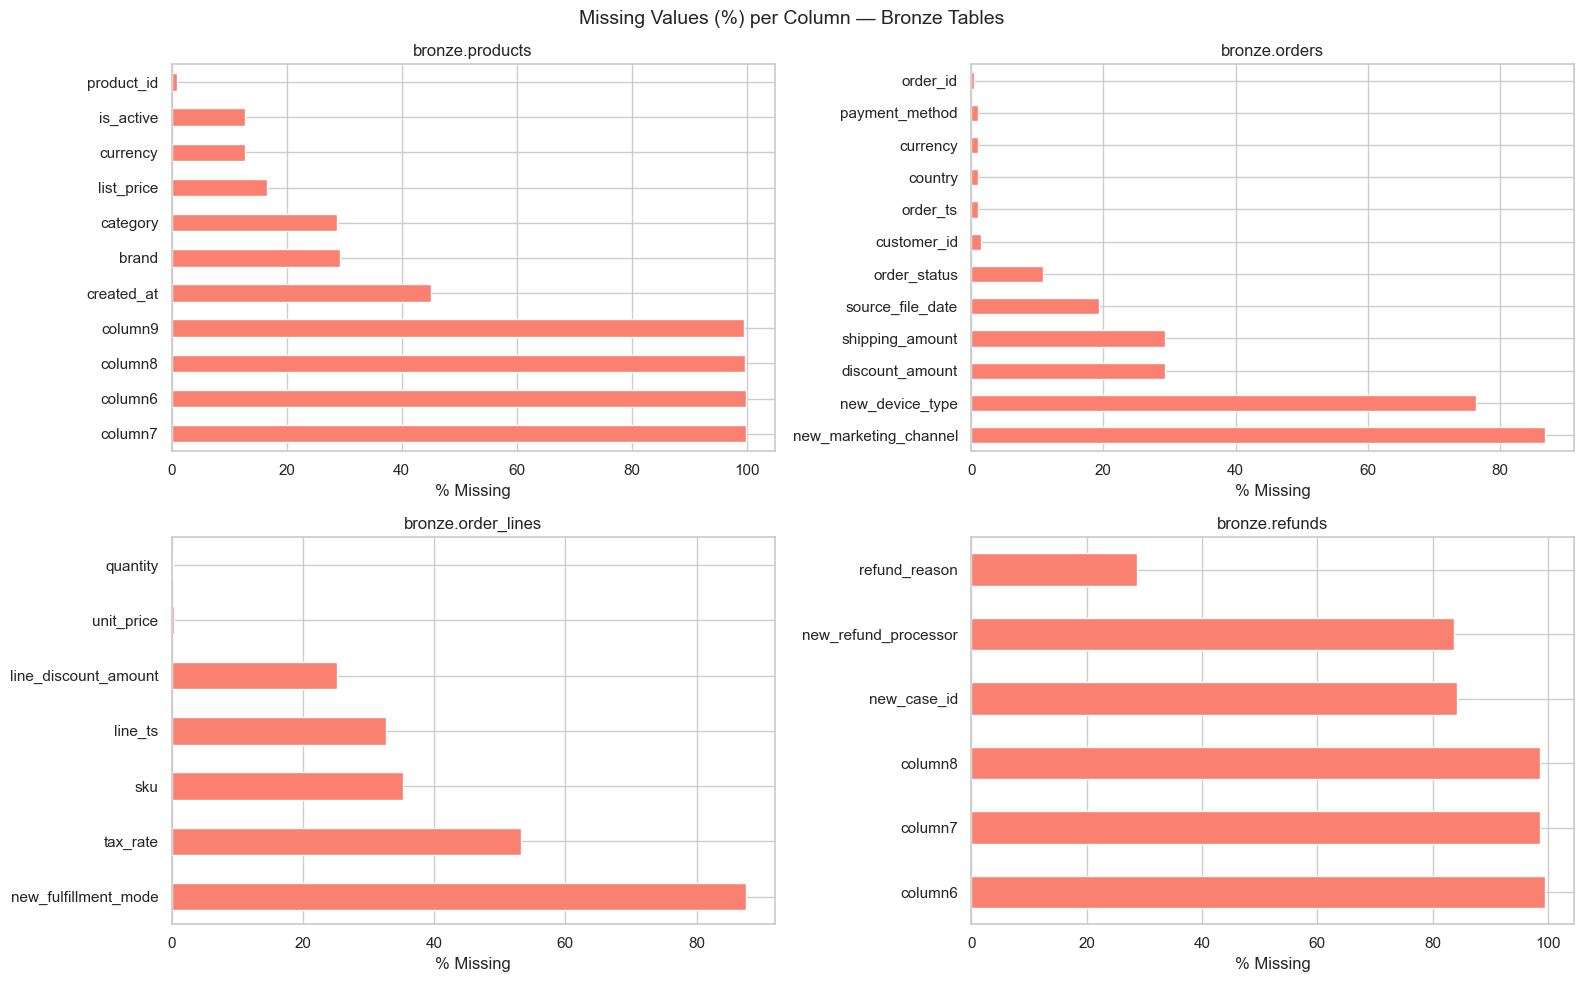

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Missing Values (%) per Column — Bronze Tables", fontsize=14)

for ax, (name, df) in zip(axes.flat, [("products", df_products), ("orders", df_orders),
                                        ("order_lines", df_order_lines), ("refunds", df_refunds)]):
    null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    null_pct = null_pct[null_pct > 0]
    if len(null_pct) > 0:
        null_pct.plot.barh(ax=ax, color="salmon")
        ax.set_xlabel("% Missing")
    else:
        ax.text(0.5, 0.5, "No missing values", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(f"bronze.{name}")

plt.tight_layout()
plt.show()

## 6. Descriptive Statistics

Summary statistics for numeric-like columns. Since bronze stores everything as `VARCHAR`, we'll cast and describe the key numeric fields.

In [12]:
# Products: cost_price and list_price distributions
con.sql("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(TRY_CAST(cost_price AS DECIMAL(10,2))) AS valid_cost_price,
        COUNT(*) - COUNT(TRY_CAST(cost_price AS DECIMAL(10,2))) AS invalid_cost_price,
        MIN(TRY_CAST(cost_price AS DECIMAL(10,2))) AS min_cost,
        AVG(TRY_CAST(cost_price AS DECIMAL(10,2))) AS avg_cost,
        MAX(TRY_CAST(cost_price AS DECIMAL(10,2))) AS max_cost,
        COUNT(TRY_CAST(list_price AS DECIMAL(10,2))) AS valid_list_price,
        COUNT(*) - COUNT(TRY_CAST(list_price AS DECIMAL(10,2))) AS invalid_list_price,
        MIN(TRY_CAST(list_price AS DECIMAL(10,2))) AS min_list,
        MAX(TRY_CAST(list_price AS DECIMAL(10,2))) AS max_list
    FROM bronze.products
""").show()

┌────────────┬──────────────────┬────────────────────┬───────────────┬───────────────────┬───────────────┬──────────────────┬────────────────────┬───────────────┬───────────────┐
│ total_rows │ valid_cost_price │ invalid_cost_price │   min_cost    │     avg_cost      │   max_cost    │ valid_list_price │ invalid_list_price │   min_list    │   max_list    │
│   int64    │      int64       │       int64        │ decimal(10,2) │      double       │ decimal(10,2) │      int64       │       int64        │ decimal(10,2) │ decimal(10,2) │
├────────────┼──────────────────┼────────────────────┼───────────────┼───────────────────┼───────────────┼──────────────────┼────────────────────┼───────────────┼───────────────┤
│        745 │              731 │                 14 │          4.15 │ 67.39303693570452 │        120.75 │              616 │                129 │        -19.99 │        314.75 │
└────────────┴──────────────────┴────────────────────┴───────────────┴───────────────────┴───────────────

In [13]:
# Orders: categorical distributions
print("Order status distribution:")
print(df_orders["order_status"].value_counts().to_string())
print(f"\nPayment methods:")
print(df_orders["payment_method"].value_counts().to_string())
print(f"\nCountries:")
print(df_orders["country"].value_counts().to_string())

Order status distribution:
order_status
shipped       264
delivered     261
paid          252
placed        251
cancelled     244
teleported      6

Payment methods:
payment_method
gift_card         376
card              349
paypal            345
klarna            342
cash_in_pigeon      7

Countries:
country
DE    247
FR    235
US    235
SE    235
NL    234
GB    226
XX      7


## 7. Duplicate Detection

The data generator intentionally injects ~4-5% duplicate rows per day per table. Let's measure the actual duplication rate.

In [14]:
con.sql("""
    SELECT 'products' AS table_name,
        COUNT(*) AS total_rows,
        COUNT(*) - COUNT(DISTINCT product_id) AS duplicate_rows,
        ROUND((COUNT(*) - COUNT(DISTINCT product_id))::FLOAT / COUNT(*) * 100, 1) AS dup_pct
    FROM bronze.products
    UNION ALL
    SELECT 'orders',
        COUNT(*),
        COUNT(*) - COUNT(DISTINCT order_id),
        ROUND((COUNT(*) - COUNT(DISTINCT order_id))::FLOAT / COUNT(*) * 100, 1)
    FROM bronze.orders
    UNION ALL
    SELECT 'order_lines',
        COUNT(*),
        COUNT(*) - COUNT(DISTINCT order_line_id),
        ROUND((COUNT(*) - COUNT(DISTINCT order_line_id))::FLOAT / COUNT(*) * 100, 1)
    FROM bronze.order_lines
    UNION ALL
    SELECT 'refunds',
        COUNT(*),
        COUNT(*) - COUNT(DISTINCT refund_id),
        ROUND((COUNT(*) - COUNT(DISTINCT refund_id))::FLOAT / COUNT(*) * 100, 1)
    FROM bronze.refunds
""").show()

┌─────────────┬────────────┬────────────────┬─────────┐
│ table_name  │ total_rows │ duplicate_rows │ dup_pct │
│   varchar   │   int64    │     int64      │  float  │
├─────────────┼────────────┼────────────────┼─────────┤
│ products    │        745 │            624 │    83.8 │
│ orders      │       1433 │             71 │     5.0 │
│ order_lines │       3646 │            132 │     3.6 │
│ refunds     │        406 │             28 │     6.9 │
└─────────────┴────────────┴────────────────┴─────────┘



## 8. Outlier Detection and Visualization

Look at numeric field distributions to spot injected bad records (negative prices, extreme values).

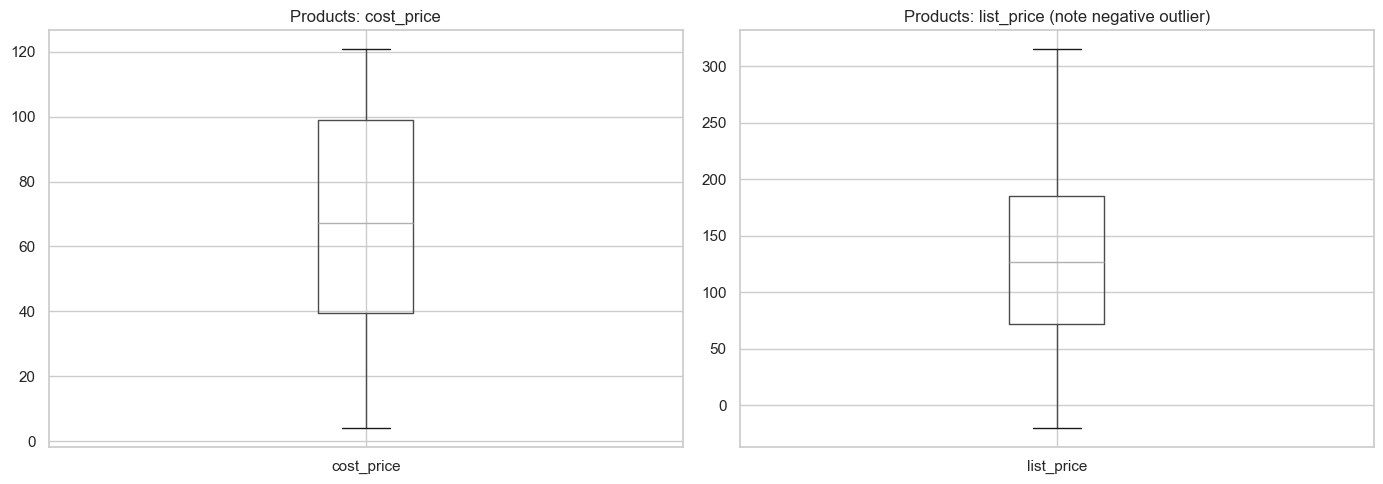

In [15]:
# Cast numeric fields for visualization (invalid values become NaN)
products_numeric = con.sql("""
    SELECT TRY_CAST(cost_price AS FLOAT) AS cost_price,
           TRY_CAST(list_price AS FLOAT) AS list_price
    FROM bronze.products
""").df()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
products_numeric.boxplot(column="cost_price", ax=axes[0])
axes[0].set_title("Products: cost_price")
products_numeric.boxplot(column="list_price", ax=axes[1])
axes[1].set_title("Products: list_price (note negative outlier)")
plt.tight_layout()
plt.show()

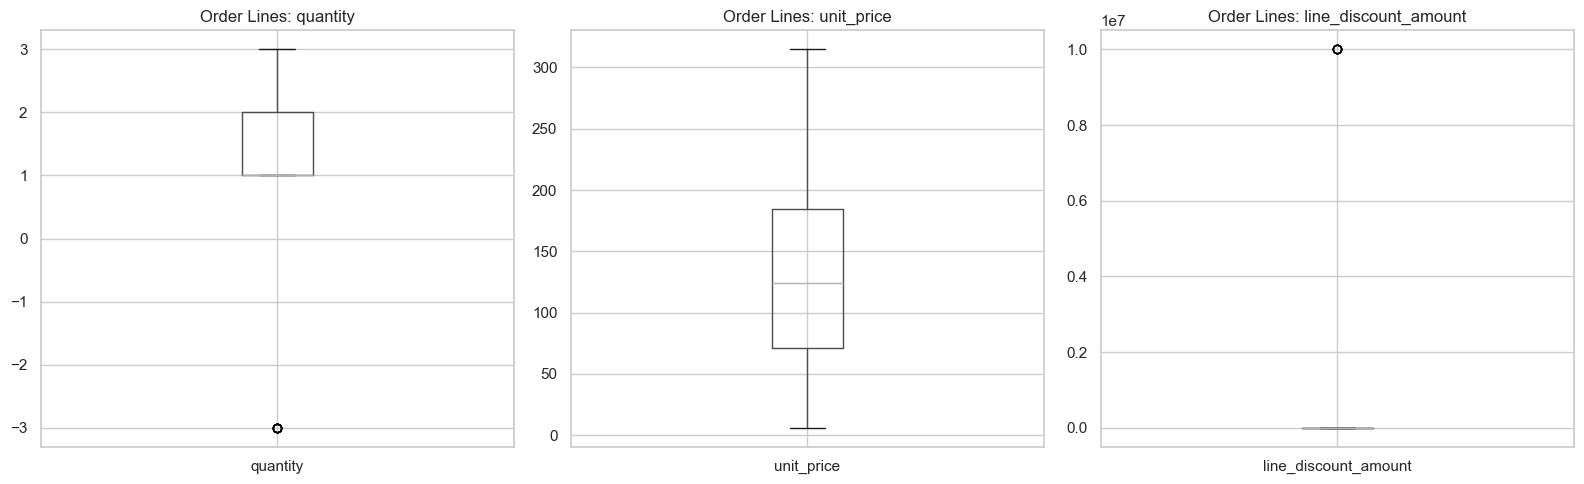

In [16]:
# Order lines: unit_price and quantity outliers
order_lines_numeric = con.sql("""
    SELECT TRY_CAST(quantity AS INT) AS quantity,
           TRY_CAST(unit_price AS FLOAT) AS unit_price,
           TRY_CAST(line_discount_amount AS FLOAT) AS line_discount_amount
    FROM bronze.order_lines
""").df()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
order_lines_numeric.boxplot(column="quantity", ax=axes[0])
axes[0].set_title("Order Lines: quantity")
order_lines_numeric.boxplot(column="unit_price", ax=axes[1])
axes[1].set_title("Order Lines: unit_price")
order_lines_numeric.boxplot(column="line_discount_amount", ax=axes[2])
axes[2].set_title("Order Lines: line_discount_amount")
plt.tight_layout()
plt.show()

## 9. Value Distribution Analysis

Distribution of key categorical and numeric fields across the bronze data.

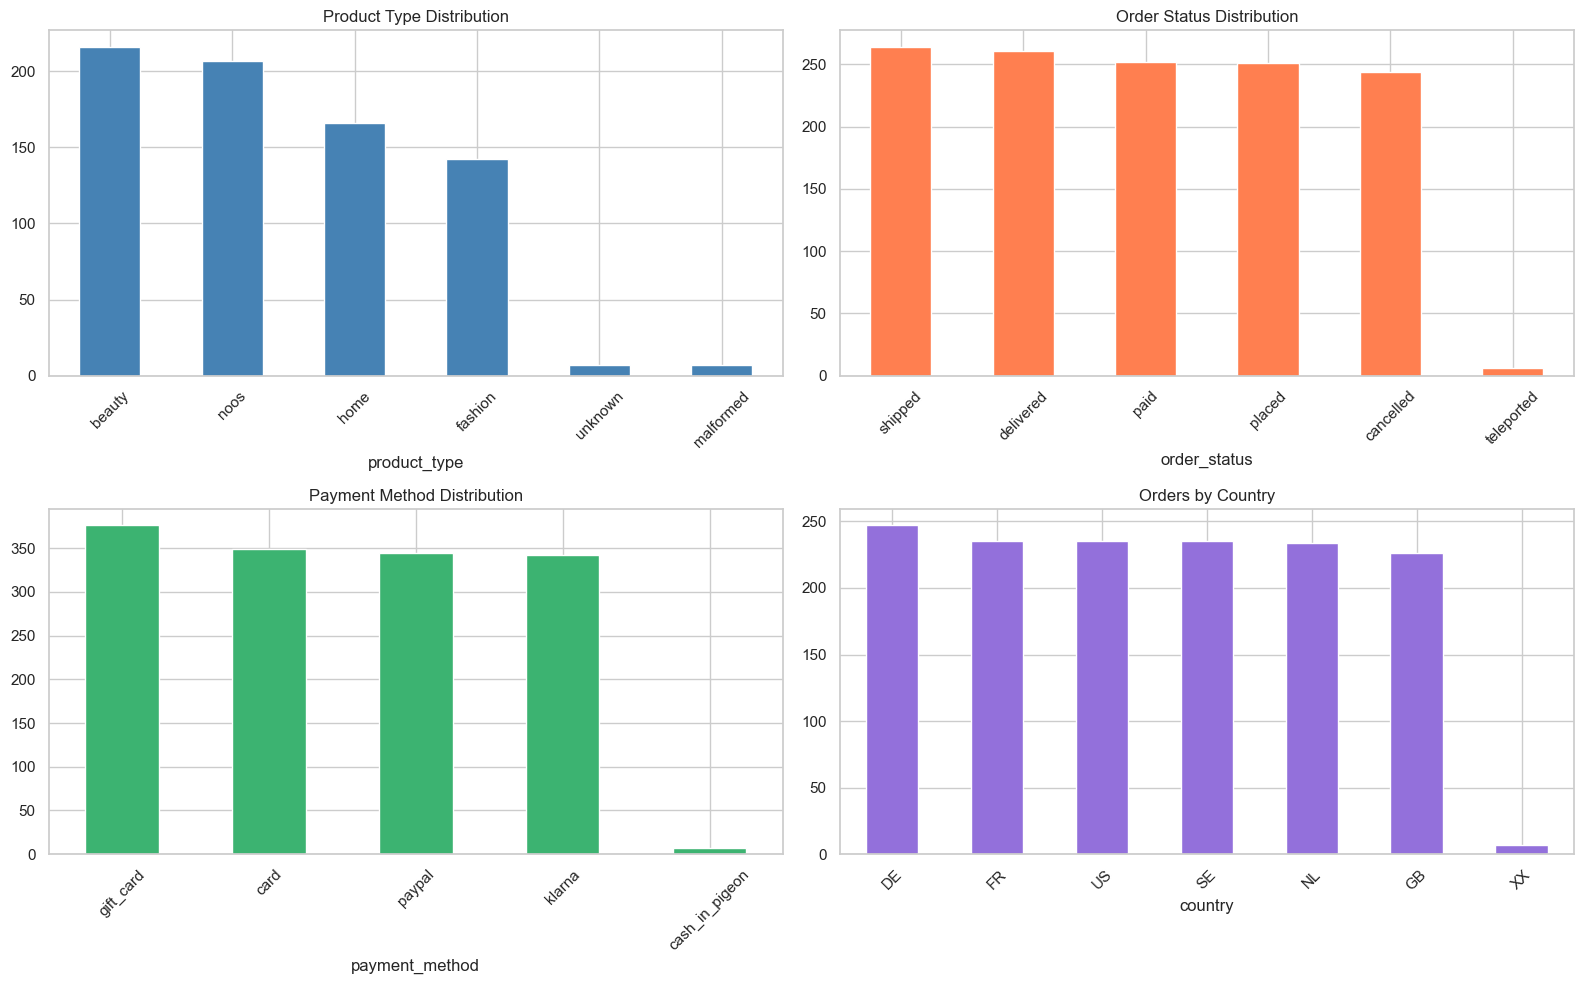

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Product types
df_products["product_type"].value_counts().plot.bar(ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Product Type Distribution")
axes[0, 0].tick_params(axis="x", rotation=45)

# Order status
df_orders["order_status"].value_counts().plot.bar(ax=axes[0, 1], color="coral")
axes[0, 1].set_title("Order Status Distribution")
axes[0, 1].tick_params(axis="x", rotation=45)

# Payment methods
df_orders["payment_method"].value_counts().plot.bar(ax=axes[1, 0], color="mediumseagreen")
axes[1, 0].set_title("Payment Method Distribution")
axes[1, 0].tick_params(axis="x", rotation=45)

# Country
df_orders["country"].value_counts().plot.bar(ax=axes[1, 1], color="mediumpurple")
axes[1, 1].set_title("Orders by Country")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 10. Data Transformation — Bad Records Found

These are the specific data quality issues that were discovered during exploration and led to the validation rules in the `transform` layer.

**Issues found:**
- **Products:** `product_id` not starting with 'P' (empty IDs), `list_price` not castable to float (`not_a_number`, missing values)
- **Orders:** `order_id` 2nd character not numeric (`O-BAD-001`), `order_ts` not a valid timestamp (`not-a-timestamp`)
- **Order Lines:** `order_line_id` 2nd character not numeric (`L-BAD-ORPHAN`), `unit_price` not castable to float (`NaN`)
- **Refunds:** `refund_id` 2nd character not numeric (`R-BAD-001`), `refund_ts` not a valid timestamp (`32/13/2026`)

In [18]:
# Sample bad records from each table
print("=== Bad Products (invalid product_id or list_price) ===")
con.sql("""
    SELECT product_id, sku, product_name, cost_price, list_price
    FROM bronze.products
    WHERE SUBSTRING(product_id, 1, 1) != 'P' OR product_id IS NULL OR product_id = ''
       OR TRY_CAST(list_price AS FLOAT) IS NULL
    LIMIT 10
""").show()

print("\n=== Bad Orders (invalid order_id or timestamp) ===")
con.sql("""
    SELECT order_id, customer_id, order_ts, country, currency
    FROM bronze.orders
    WHERE TRY_CAST(SUBSTRING(order_id, 2, 1) AS INT) IS NULL
       OR TRY_CAST(order_ts AS DATETIME) IS NULL
    LIMIT 10
""").show()

print("\n=== Bad Order Lines (invalid order_line_id or unit_price) ===")
con.sql("""
    SELECT order_line_id, order_id, product_id, quantity, unit_price
    FROM bronze.order_lines
    WHERE TRY_CAST(SUBSTRING(order_line_id, 2, 1) AS INT) IS NULL
       OR TRY_CAST(unit_price AS FLOAT) IS NULL
    LIMIT 10
""").show()

print("\n=== Bad Refunds (invalid refund_id or timestamp) ===")
con.sql("""
    SELECT refund_id, order_line_id, refund_ts, refund_amount
    FROM bronze.refunds
    WHERE TRY_CAST(SUBSTRING(refund_id, 2, 1) AS INT) IS NULL
       OR TRY_CAST(refund_ts AS DATETIME) IS NULL
    LIMIT 10
""").show()

=== Bad Products (invalid product_id or list_price) ===
┌────────────┬─────────┬────────────────┬──────────────┬────────────┐
│ product_id │   sku   │  product_name  │  cost_price  │ list_price │
│  varchar   │ varchar │    varchar     │   varchar    │  varchar   │
├────────────┼─────────┼────────────────┼──────────────┼────────────┤
│ NULL       │ ???     │ BROKEN_PRODUCT │ not_a_number │ -19.99     │
│ this       │ is      │ a              │ row          │ with       │
│ NULL       │ ???     │ BROKEN_PRODUCT │ not_a_number │ -19.99     │
│ this       │ is      │ a              │ row          │ too        │
│ NULL       │ ???     │ BROKEN_PRODUCT │ not_a_number │ -19.99     │
│ this       │ is      │ a              │ row          │ many       │
│ NULL       │ ???     │ BROKEN_PRODUCT │ not_a_number │ -19.99     │
│ this       │ is      │ a              │ row          │ many       │
│ NULL       │ ???     │ BROKEN_PRODUCT │ not_a_number │ -19.99     │
│ this       │ is      │ a        

## 11. Data Validation — Quality Summary

Results from the `data_quality` schema, showing how many records pass vs fail validation in each table.

In [19]:
print("=== Data Quality: Products ===")
con.sql("SELECT * FROM data_quality.products ORDER BY error_count DESC").show()

print("=== Data Quality: Orders ===")
con.sql("SELECT * FROM data_quality.orders ORDER BY error_count DESC").show()

print("=== Data Quality: Order Lines ===")
con.sql("SELECT * FROM data_quality.order_lines ORDER BY error_count DESC").show()

print("=== Data Quality: Refunds ===")
con.sql("SELECT * FROM data_quality.refunds ORDER BY error_count DESC").show()

=== Data Quality: Products ===
┌────────────────────┬─────────────┬───────────────────────────────┐
│    error_reason    │ error_count │           run_time            │
│      varchar       │    int64    │   timestamp with time zone    │
├────────────────────┼─────────────┼───────────────────────────────┤
│ VALID              │         738 │ 2026-03-17 19:54:38.403566+01 │
│ INVALID_PRODUCT_ID │           7 │ 2026-03-17 19:54:38.403566+01 │
└────────────────────┴─────────────┴───────────────────────────────┘

=== Data Quality: Orders ===
┌────────────────────────────────────┬─────────────┬───────────────────────────────┐
│            error_reason            │ error_count │           run_time            │
│              varchar               │    int64    │   timestamp with time zone    │
├────────────────────────────────────┼─────────────┼───────────────────────────────┤
│ VALID                              │        1412 │ 2026-03-17 19:48:22.352864+01 │
│ INVALID_ORDER_ID|INVALID_TIME

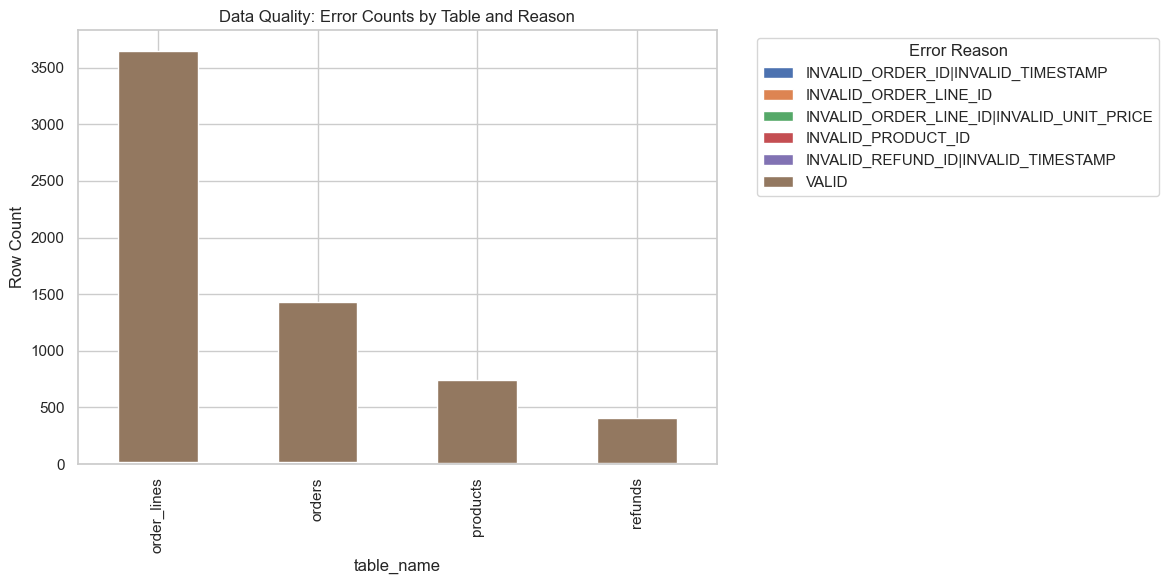

In [20]:
# Visualize error distribution across all tables
dq = con.sql("""
    SELECT 'products' AS table_name, error_reason, error_count FROM data_quality.products
    UNION ALL
    SELECT 'orders', error_reason, error_count FROM data_quality.orders
    UNION ALL
    SELECT 'order_lines', error_reason, error_count FROM data_quality.order_lines
    UNION ALL
    SELECT 'refunds', error_reason, error_count FROM data_quality.refunds
""").df()

fig, ax = plt.subplots(figsize=(12, 6))
pivot = dq.pivot_table(index="table_name", columns="error_reason", values="error_count", fill_value=0)
pivot.plot.bar(ax=ax, stacked=True)
ax.set_title("Data Quality: Error Counts by Table and Reason")
ax.set_ylabel("Row Count")
ax.legend(title="Error Reason", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 12. Bronze vs Silver — Pipeline Validation

Compare row counts between bronze (raw) and silver (cleaned, deduped, validated) to confirm the pipeline is filtering correctly.

,table_name,bronze_rows,silver_rows,rows_removed
0,products,745,120,625
1,orders,1433,1360,73
2,order_lines,3646,3511,135
3,refunds,406,376,30


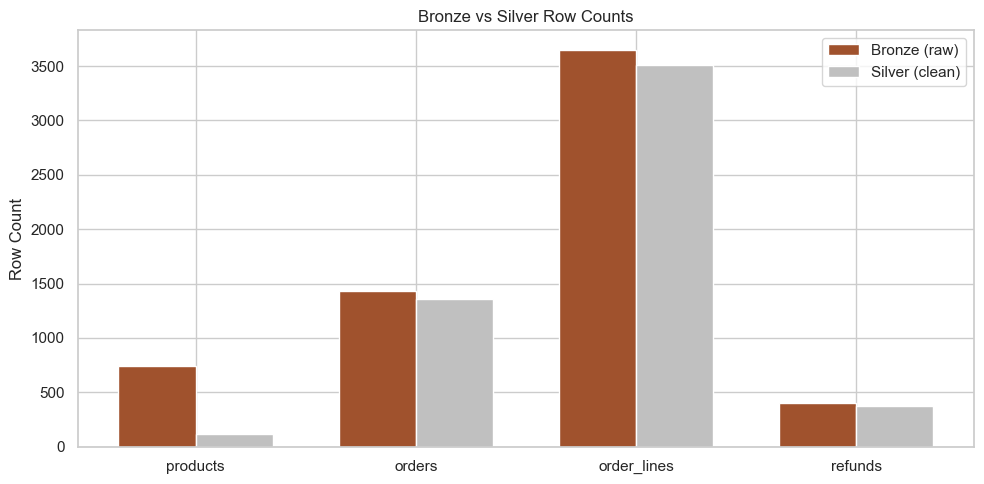

In [21]:
comparison = con.sql("""
    SELECT 'products' AS table_name,
        (SELECT COUNT(*) FROM bronze.products) AS bronze_rows,
        (SELECT COUNT(*) FROM silver.products) AS silver_rows,
        (SELECT COUNT(*) FROM bronze.products) - (SELECT COUNT(*) FROM silver.products) AS rows_removed
    UNION ALL
    SELECT 'orders',
        (SELECT COUNT(*) FROM bronze.orders),
        (SELECT COUNT(*) FROM silver.orders),
        (SELECT COUNT(*) FROM bronze.orders) - (SELECT COUNT(*) FROM silver.orders)
    UNION ALL
    SELECT 'order_lines',
        (SELECT COUNT(*) FROM bronze.order_lines),
        (SELECT COUNT(*) FROM silver.order_lines),
        (SELECT COUNT(*) FROM bronze.order_lines) - (SELECT COUNT(*) FROM silver.order_lines)
    UNION ALL
    SELECT 'refunds',
        (SELECT COUNT(*) FROM bronze.refunds),
        (SELECT COUNT(*) FROM silver.refunds),
        (SELECT COUNT(*) FROM bronze.refunds) - (SELECT COUNT(*) FROM silver.refunds)
""").df()

display(comparison)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison))
width = 0.35
ax.bar(x - width/2, comparison["bronze_rows"], width, label="Bronze (raw)", color="sienna")
ax.bar(x + width/2, comparison["silver_rows"], width, label="Silver (clean)", color="silver")
ax.set_xticks(x)
ax.set_xticklabels(comparison["table_name"])
ax.set_ylabel("Row Count")
ax.set_title("Bronze vs Silver Row Counts")
ax.legend()
plt.tight_layout()
plt.show()

In [26]:
con.sql("SELECT table_schema, table_name FROM information_schema.tables WHERE table_schema = 'gold'").show()

┌──────────────┬────────────┐
│ table_schema │ table_name │
│   varchar    │  varchar   │
├──────────────┼────────────┤
│ gold         │ DimOrder   │
│ gold         │ DimProduct │
│ gold         │ DimRefund  │
│ gold         │ FactRefund │
└──────────────┴────────────┘



In [27]:
con.close()
print("Connection closed.")

Connection closed.
